# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [2]:
from datetime import datetime, timedelta
import re

end_time = None
start_time = None
elapsed_hms = None

with open("run.log") as f:
    lines = [line.strip() for line in f if line.strip()]

# 最後一行 = End Time
end_time_str = lines[-1]
end_time = datetime.strptime(end_time_str, "%a %b %d %H:%M:%S %Z %Y")

# 找 Total run time
elapsed_sec = None

for line in lines:
    if line.startswith("Total run time"):
        m = re.search(r'([\d.]+)', line)
        if m:
            elapsed_sec = float(m.group(1))
        break

if elapsed_sec is not None:
    start_time = end_time - timedelta(seconds=elapsed_sec)

    h = int(elapsed_sec // 3600)
    m = int((elapsed_sec % 3600) // 60)
    s = int(elapsed_sec % 60)

    elapsed_hms = f"{h:02d}:{m:02d}:{s:02d}"

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"End Time   : {end_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"Run Time   : {elapsed_hms}")

Simulation Information
----------------------
Start Time : Fri Jun 26 01:43:49 2026
End Time   : Fri Jun 26 05:08:19 2026
Run Time   : 03:24:29


# 使用者設定

In [3]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -8.000e+09
  BETA = 1.500e+11
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 8.000e-09 m


## Utils

In [4]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [5]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00000628
   plt00000835
   plt00001156
   plt00001918
   plt00002971
   plt00006742
   plt00009239
   plt00011172
   plt00013828
   plt00015456
   plt00016549
   plt00017437
   plt00019269
   plt00019918
   plt00020641
   plt00021242
   plt00021878
   plt00022493
   plt00023096
   plt00023458
   plt00024167
   plt00025219
   plt00026216
   plt00031232
   plt00034412
   plt00036784
   plt00039995
   plt00052933
   plt00054505
   plt00055378
   plt00055986
   plt00057363
   plt00058328
   plt00059247
   plt00059882
   plt00060153
   plt00061255
   plt00061504
   plt00061915
   plt00062641
   plt00067213
   plt00071247
   plt00074053
   plt00076336
   plt00078438
   plt00080747
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [6]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-26 14:41:00,052 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-26 14:41:00,052 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:00,053 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:00,053 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_withi

### 用key word查看dir(ds)中可能會用到的attribute

In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [9]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [10]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [11]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotate_func__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__static_attributes__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_s

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [12]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.95e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.475e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.95e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [13]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-25 22:50:27,800 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-25 22:50:27,800 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:27,800 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:27,801 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


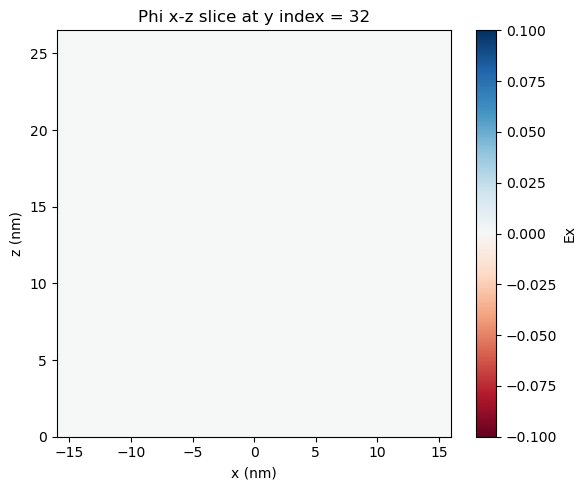

yt : [INFO     ] 2026-06-25 22:50:27,906 Parameters: current_time              = 4.622000000000162e-10
yt : [INFO     ] 2026-06-25 22:50:27,906 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:27,907 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:27,907 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


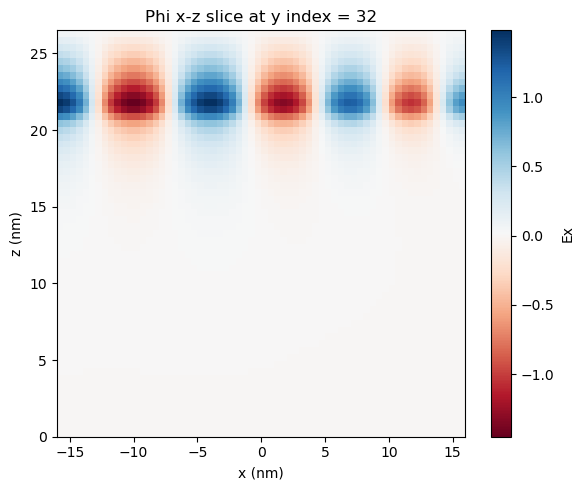

yt : [INFO     ] 2026-06-25 22:50:28,071 Parameters: current_time              = 7.363999999999594e-10
yt : [INFO     ] 2026-06-25 22:50:28,071 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,071 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,071 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


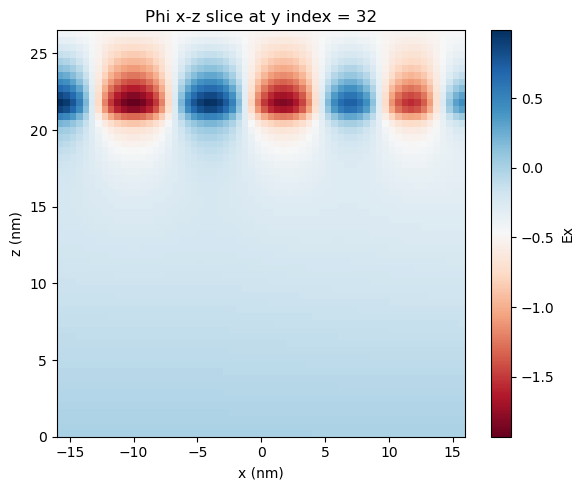

yt : [INFO     ] 2026-06-25 22:50:28,162 Parameters: current_time              = 9.85399999999935e-10
yt : [INFO     ] 2026-06-25 22:50:28,162 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,162 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,162 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


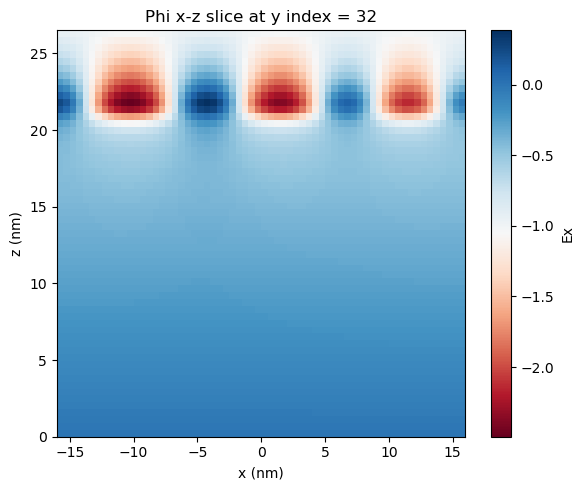

yt : [INFO     ] 2026-06-25 22:50:28,254 Parameters: current_time              = 1.330800000000041e-09
yt : [INFO     ] 2026-06-25 22:50:28,254 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,254 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,254 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


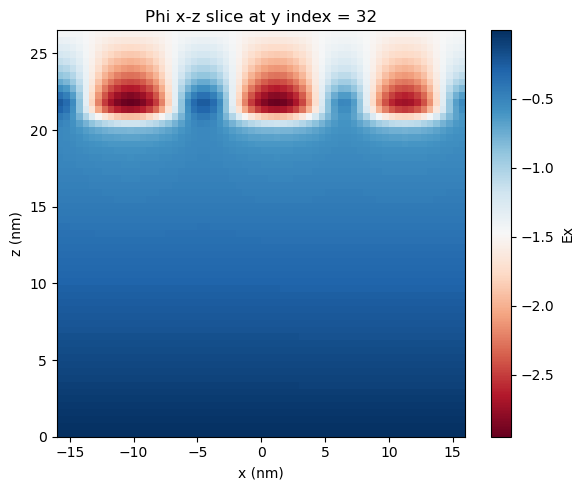

yt : [INFO     ] 2026-06-25 22:50:28,345 Parameters: current_time              = 1.6284000000001322e-09
yt : [INFO     ] 2026-06-25 22:50:28,345 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,345 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,346 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


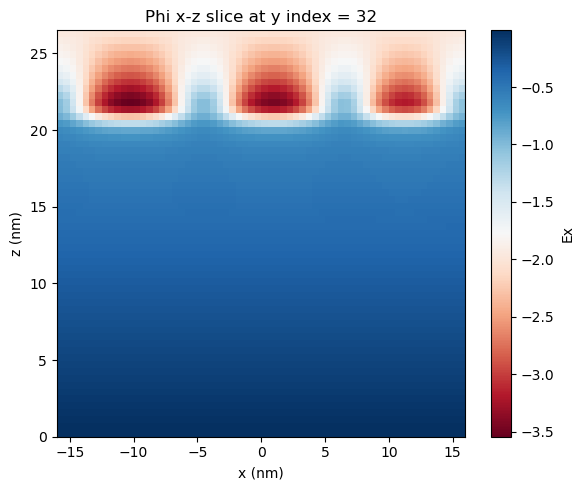

yt : [INFO     ] 2026-06-25 22:50:28,438 Parameters: current_time              = 2.0730000000002686e-09
yt : [INFO     ] 2026-06-25 22:50:28,439 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,439 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,439 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


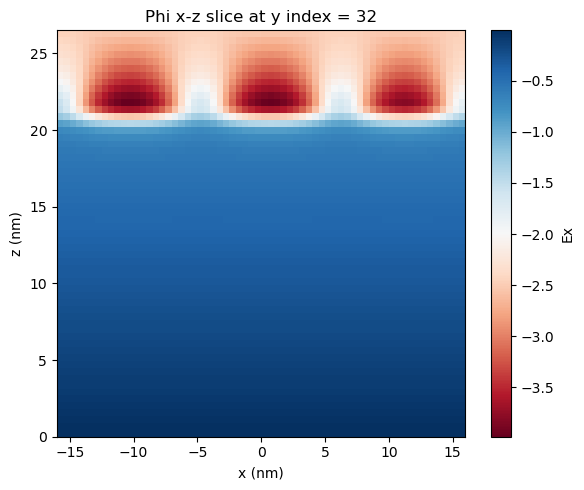

yt : [INFO     ] 2026-06-25 22:50:28,532 Parameters: current_time              = 2.4500000000003842e-09
yt : [INFO     ] 2026-06-25 22:50:28,533 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,533 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,533 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


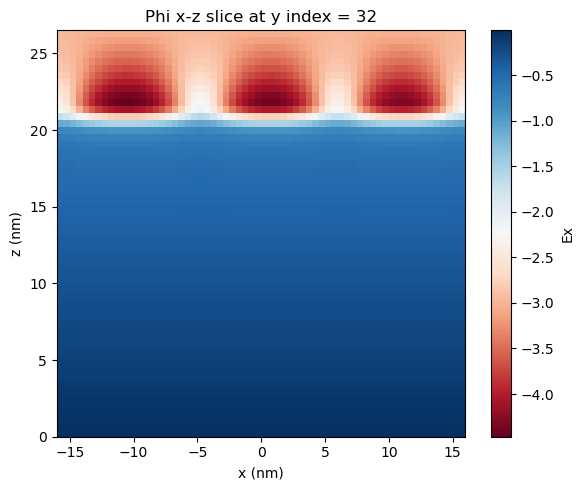

yt : [INFO     ] 2026-06-25 22:50:28,627 Parameters: current_time              = 2.7500000000004763e-09
yt : [INFO     ] 2026-06-25 22:50:28,627 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,627 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,627 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


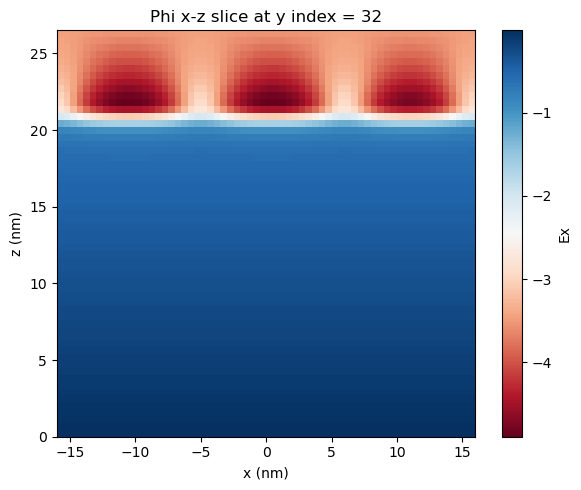

yt : [INFO     ] 2026-06-25 22:50:28,717 Parameters: current_time              = 3.4296000000006847e-09
yt : [INFO     ] 2026-06-25 22:50:28,718 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,718 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,718 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


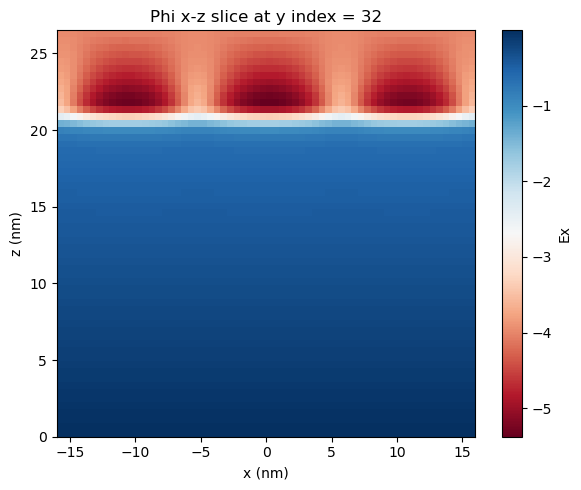

yt : [INFO     ] 2026-06-25 22:50:28,808 Parameters: current_time              = 3.985600000000855e-09
yt : [INFO     ] 2026-06-25 22:50:28,808 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,809 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,809 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


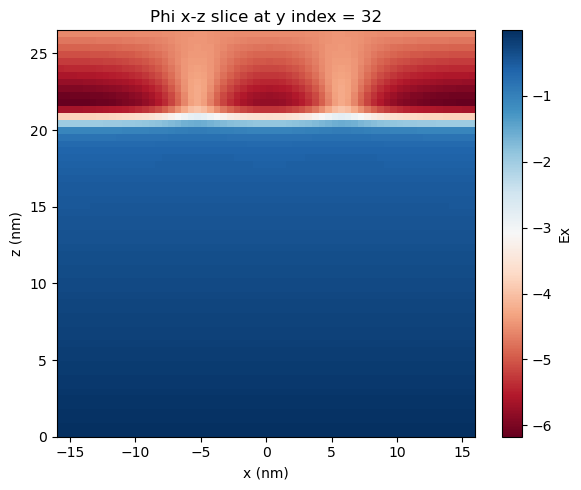

yt : [INFO     ] 2026-06-25 22:50:28,900 Parameters: current_time              = 4.220200000000927e-09
yt : [INFO     ] 2026-06-25 22:50:28,900 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,900 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,901 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


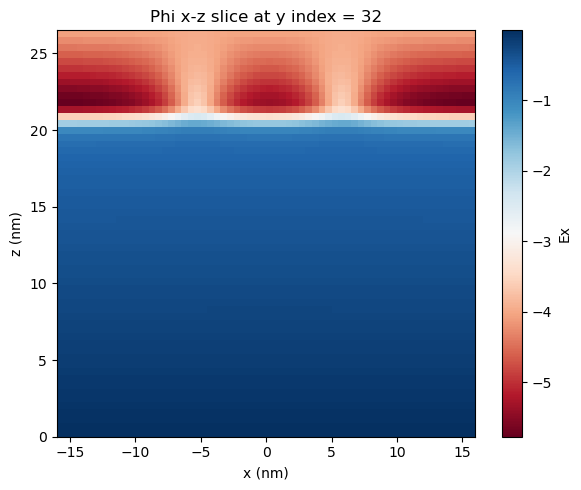

yt : [INFO     ] 2026-06-25 22:50:28,992 Parameters: current_time              = 4.476000000001006e-09
yt : [INFO     ] 2026-06-25 22:50:28,992 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:28,992 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:28,992 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


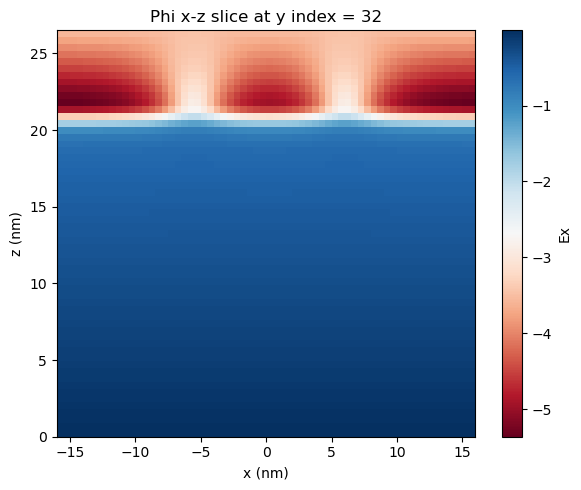

yt : [INFO     ] 2026-06-25 22:50:29,083 Parameters: current_time              = 4.7826000000011e-09
yt : [INFO     ] 2026-06-25 22:50:29,083 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,083 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,084 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


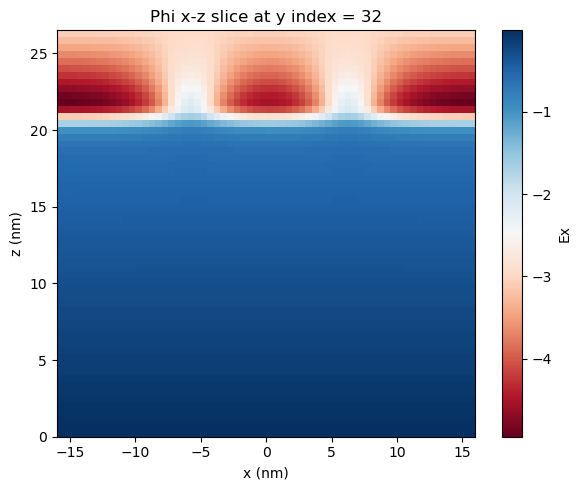

yt : [INFO     ] 2026-06-25 22:50:29,172 Parameters: current_time              = 5.1012000000011975e-09
yt : [INFO     ] 2026-06-25 22:50:29,173 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,173 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,173 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


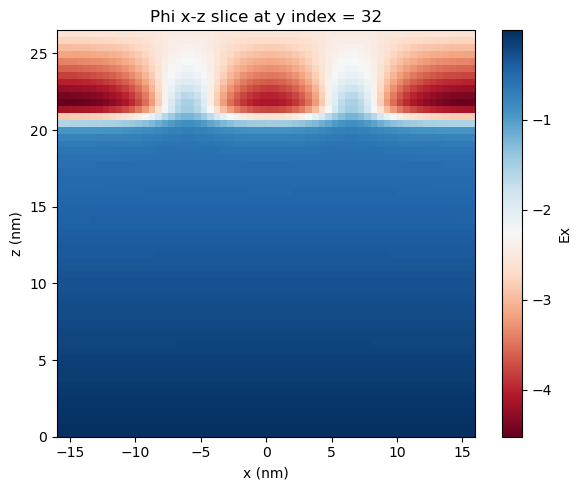

yt : [INFO     ] 2026-06-25 22:50:29,385 Parameters: current_time              = 5.350600000001274e-09
yt : [INFO     ] 2026-06-25 22:50:29,386 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,386 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,386 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


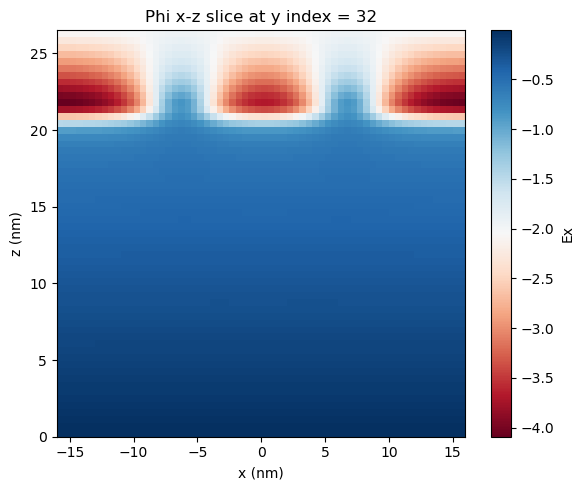

yt : [INFO     ] 2026-06-25 22:50:29,479 Parameters: current_time              = 5.615800000001355e-09
yt : [INFO     ] 2026-06-25 22:50:29,479 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,479 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,479 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


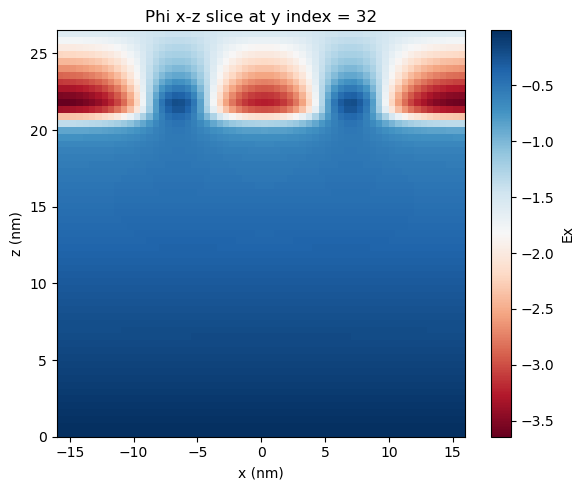

yt : [INFO     ] 2026-06-25 22:50:29,572 Parameters: current_time              = 5.9100000000014456e-09
yt : [INFO     ] 2026-06-25 22:50:29,572 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,572 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,573 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


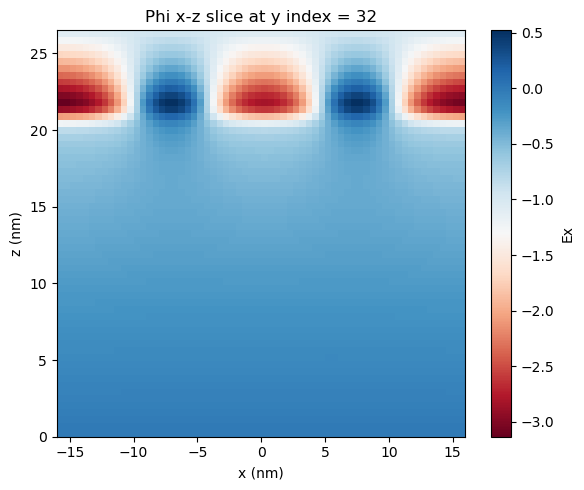

yt : [INFO     ] 2026-06-25 22:50:29,665 Parameters: current_time              = 6.361200000001584e-09
yt : [INFO     ] 2026-06-25 22:50:29,666 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,666 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,666 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


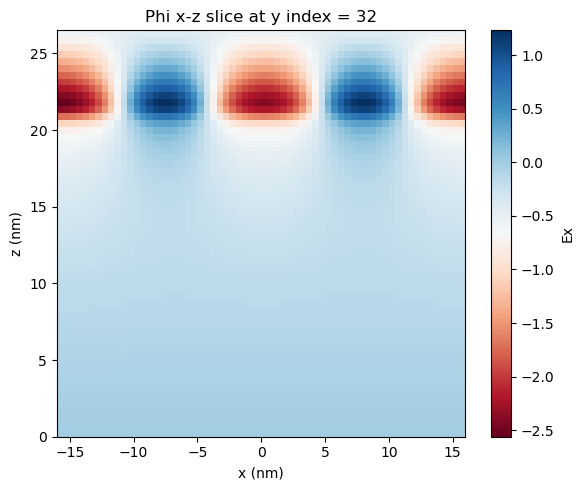

yt : [INFO     ] 2026-06-25 22:50:29,759 Parameters: current_time              = 6.646000000001671e-09
yt : [INFO     ] 2026-06-25 22:50:29,759 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,760 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,760 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


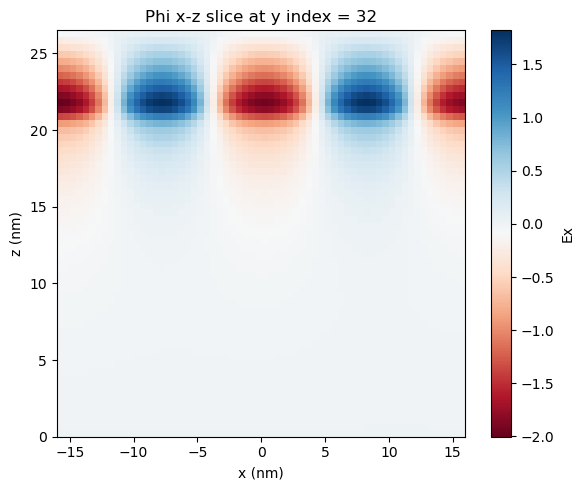

yt : [INFO     ] 2026-06-25 22:50:29,853 Parameters: current_time              = 6.978000000001773e-09
yt : [INFO     ] 2026-06-25 22:50:29,853 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,853 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,854 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


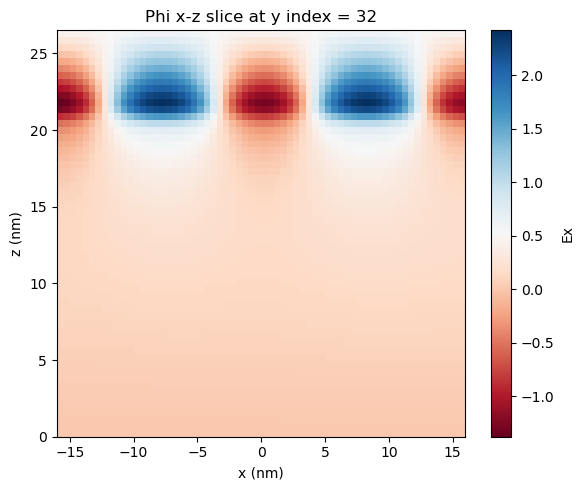

yt : [INFO     ] 2026-06-25 22:50:29,946 Parameters: current_time              = 7.848600000000393e-09
yt : [INFO     ] 2026-06-25 22:50:29,946 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:29,946 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:29,946 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


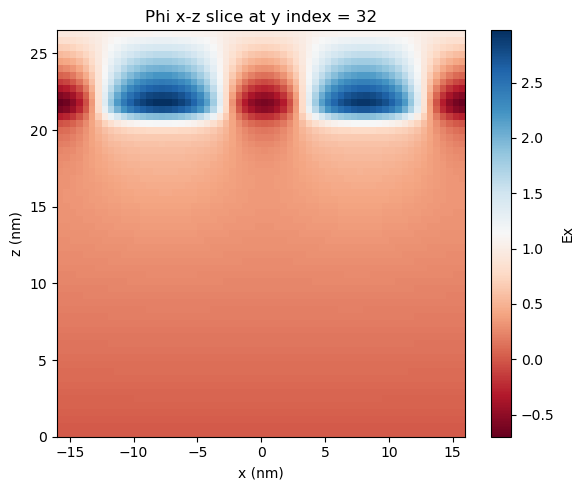

yt : [INFO     ] 2026-06-25 22:50:30,037 Parameters: current_time              = 8.609199999997481e-09
yt : [INFO     ] 2026-06-25 22:50:30,038 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,038 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,038 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


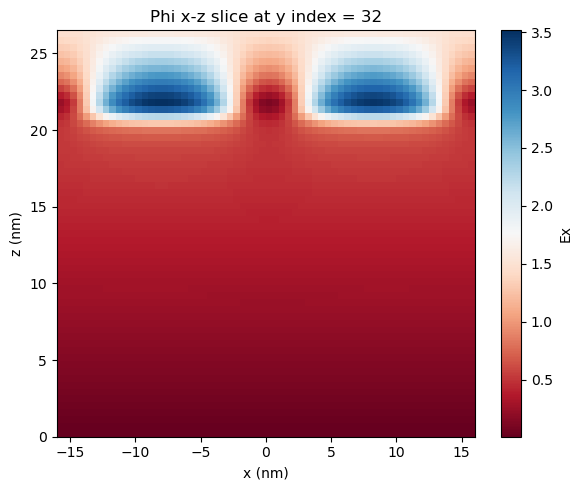

yt : [INFO     ] 2026-06-25 22:50:30,129 Parameters: current_time              = 8.924999999996272e-09
yt : [INFO     ] 2026-06-25 22:50:30,129 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,130 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,130 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


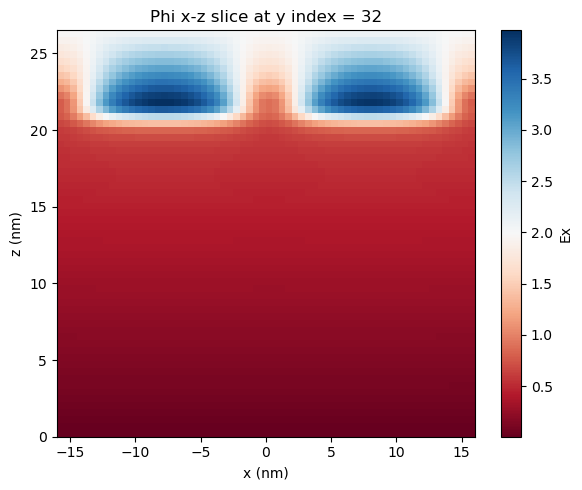

yt : [INFO     ] 2026-06-25 22:50:30,221 Parameters: current_time              = 9.284799999994894e-09
yt : [INFO     ] 2026-06-25 22:50:30,221 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,222 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,222 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


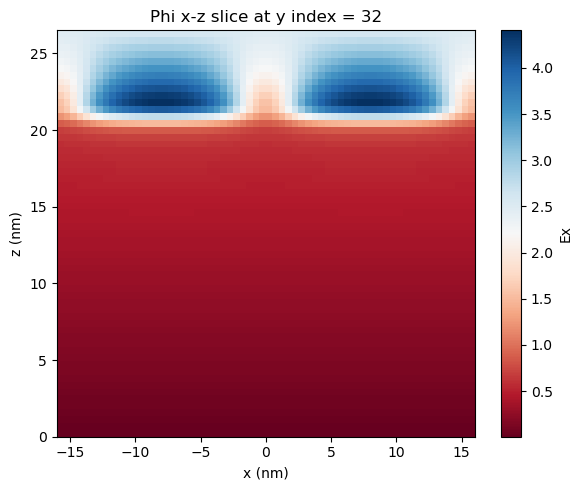

yt : [INFO     ] 2026-06-25 22:50:30,314 Parameters: current_time              = 9.794399999992943e-09
yt : [INFO     ] 2026-06-25 22:50:30,314 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,314 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,314 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


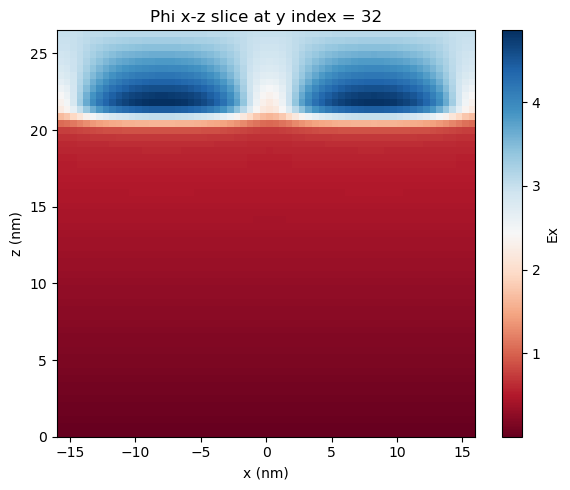

yt : [INFO     ] 2026-06-25 22:50:30,403 Parameters: current_time              = 1.0252599999991188e-08
yt : [INFO     ] 2026-06-25 22:50:30,403 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,403 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,404 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


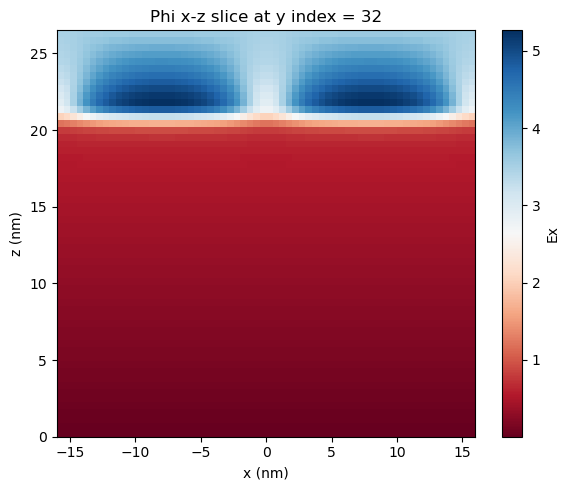

yt : [INFO     ] 2026-06-25 22:50:30,624 Parameters: current_time              = 1.0378599999990706e-08
yt : [INFO     ] 2026-06-25 22:50:30,625 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,625 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,625 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


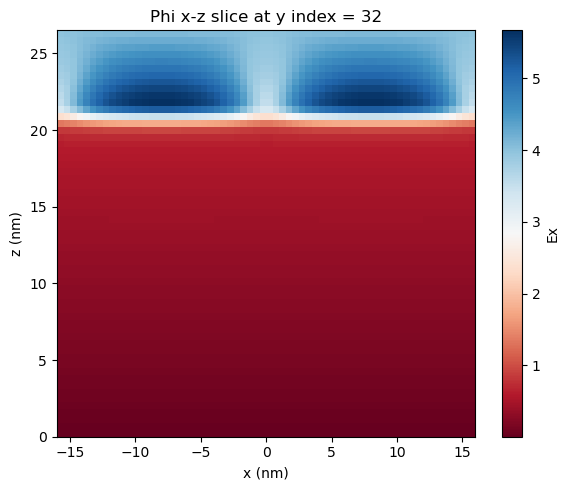

yt : [INFO     ] 2026-06-25 22:50:30,719 Parameters: current_time              = 1.117139999998767e-08
yt : [INFO     ] 2026-06-25 22:50:30,719 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,719 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,719 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


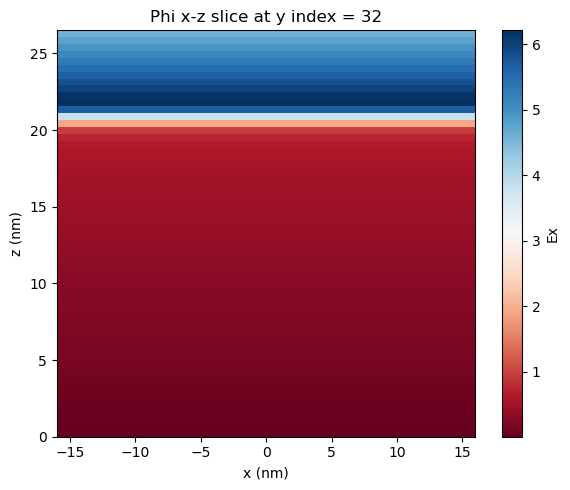

yt : [INFO     ] 2026-06-25 22:50:30,810 Parameters: current_time              = 1.1180799999987634e-08
yt : [INFO     ] 2026-06-25 22:50:30,810 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,810 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,810 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


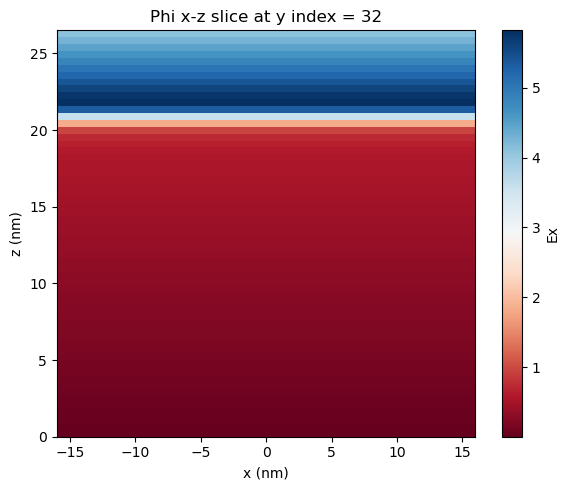

yt : [INFO     ] 2026-06-25 22:50:30,899 Parameters: current_time              = 1.1190799999987595e-08
yt : [INFO     ] 2026-06-25 22:50:30,899 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,899 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,899 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


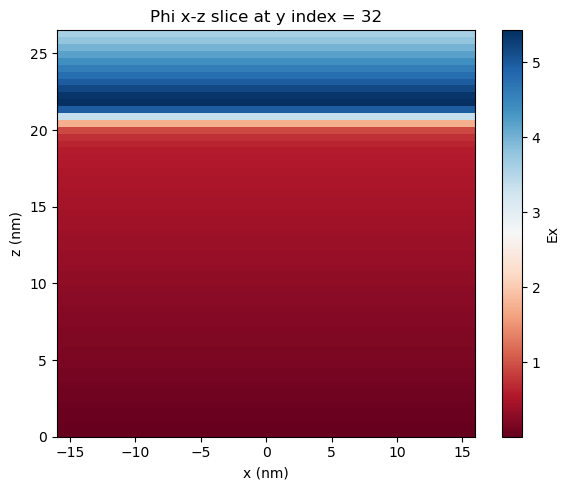

yt : [INFO     ] 2026-06-25 22:50:30,989 Parameters: current_time              = 1.1201599999987554e-08
yt : [INFO     ] 2026-06-25 22:50:30,989 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:30,990 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:30,990 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


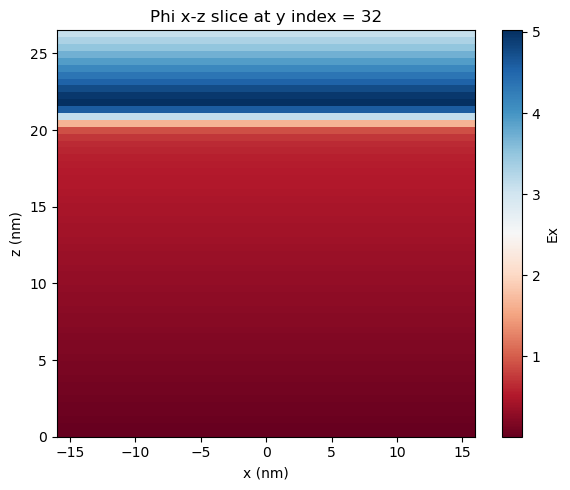

yt : [INFO     ] 2026-06-25 22:50:31,080 Parameters: current_time              = 1.121319999998751e-08
yt : [INFO     ] 2026-06-25 22:50:31,080 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,080 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,080 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


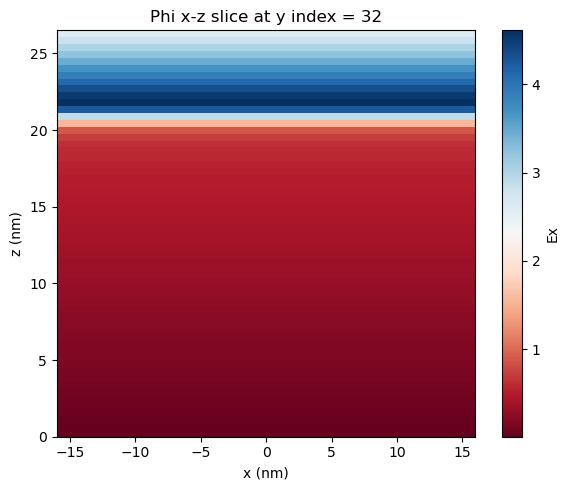

yt : [INFO     ] 2026-06-25 22:50:31,170 Parameters: current_time              = 1.122599999998746e-08
yt : [INFO     ] 2026-06-25 22:50:31,170 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,170 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,170 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


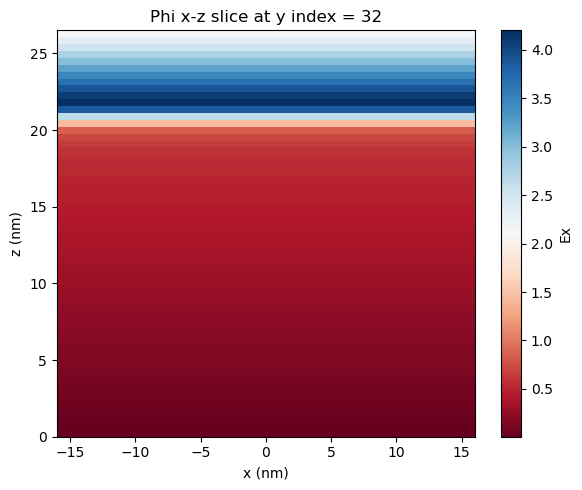

yt : [INFO     ] 2026-06-25 22:50:31,263 Parameters: current_time              = 1.1239999999987407e-08
yt : [INFO     ] 2026-06-25 22:50:31,264 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,264 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,264 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


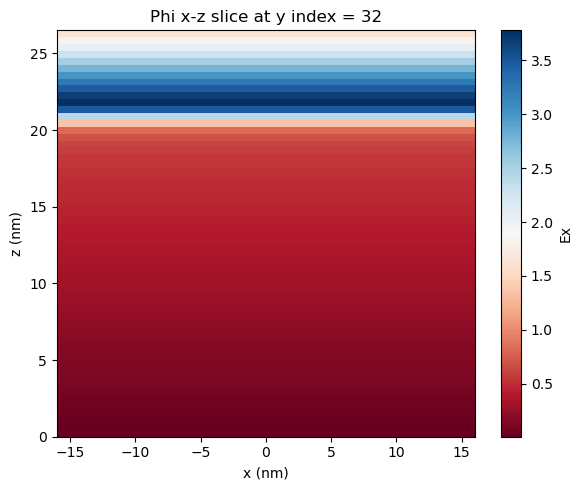

yt : [INFO     ] 2026-06-25 22:50:31,357 Parameters: current_time              = 1.1255799999987347e-08
yt : [INFO     ] 2026-06-25 22:50:31,358 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,358 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,358 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


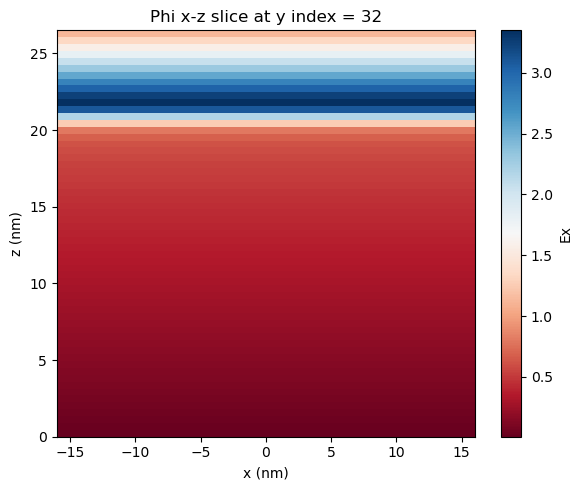

yt : [INFO     ] 2026-06-25 22:50:31,451 Parameters: current_time              = 1.1273999999987277e-08
yt : [INFO     ] 2026-06-25 22:50:31,451 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,451 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,452 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


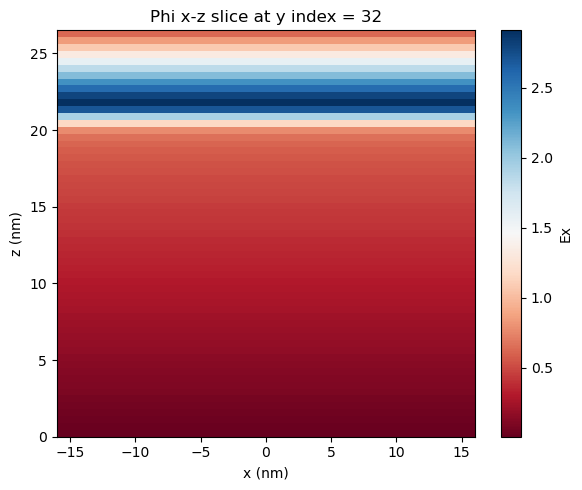

yt : [INFO     ] 2026-06-25 22:50:31,542 Parameters: current_time              = 1.1295599999987194e-08
yt : [INFO     ] 2026-06-25 22:50:31,543 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,543 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,543 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


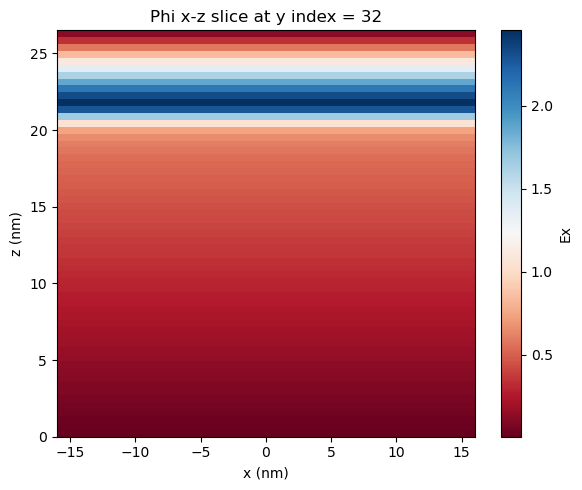

yt : [INFO     ] 2026-06-25 22:50:31,632 Parameters: current_time              = 1.132259999998709e-08
yt : [INFO     ] 2026-06-25 22:50:31,632 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,633 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,633 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


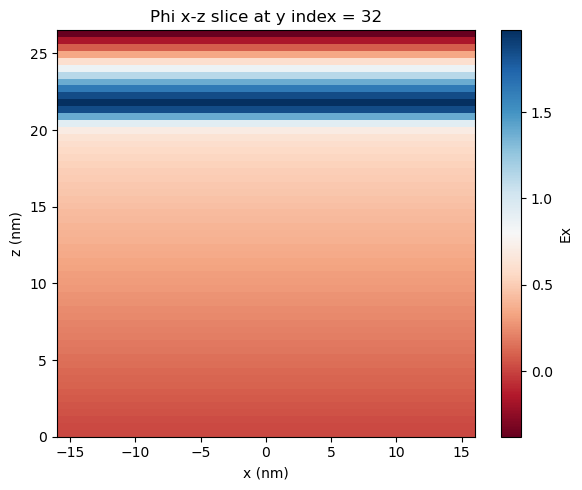

yt : [INFO     ] 2026-06-25 22:50:31,722 Parameters: current_time              = 1.1359999999986948e-08
yt : [INFO     ] 2026-06-25 22:50:31,722 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,722 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,723 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


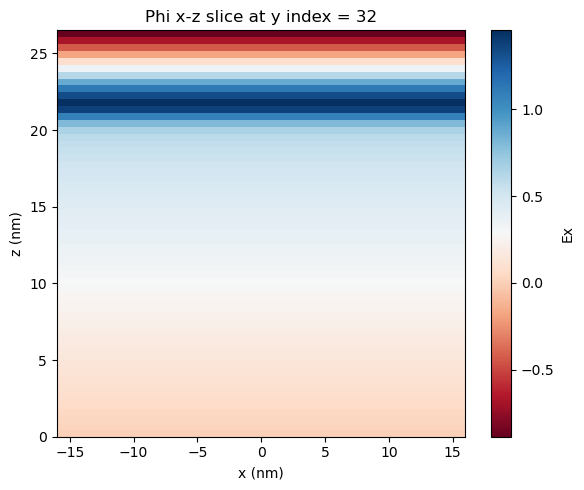

yt : [INFO     ] 2026-06-25 22:50:31,940 Parameters: current_time              = 1.1423999999986702e-08
yt : [INFO     ] 2026-06-25 22:50:31,940 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:31,940 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:31,941 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


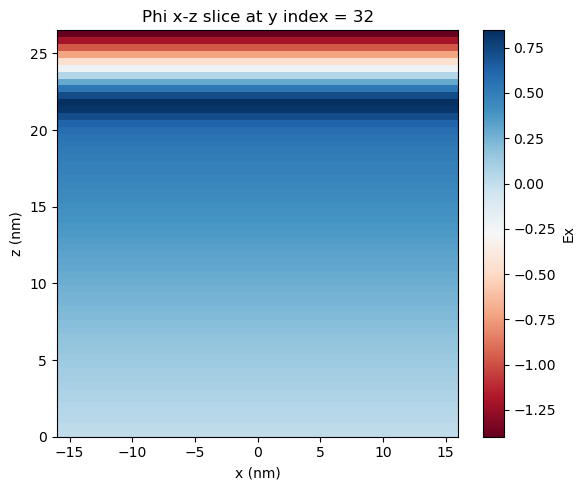

yt : [INFO     ] 2026-06-25 22:50:32,034 Parameters: current_time              = 1.1472199999986518e-08
yt : [INFO     ] 2026-06-25 22:50:32,035 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,035 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,035 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


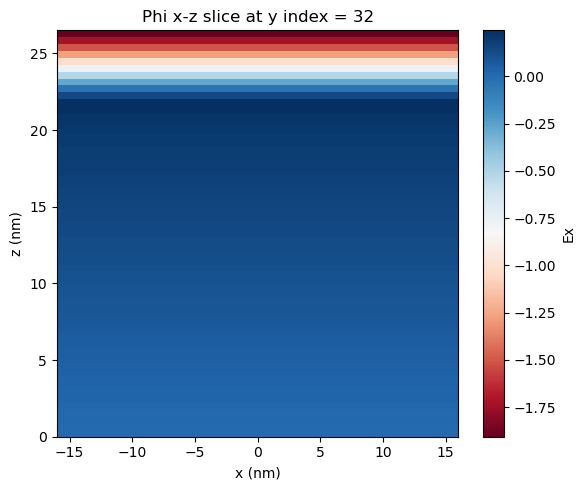

yt : [INFO     ] 2026-06-25 22:50:32,128 Parameters: current_time              = 1.1926999999984776e-08
yt : [INFO     ] 2026-06-25 22:50:32,128 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,128 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,128 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


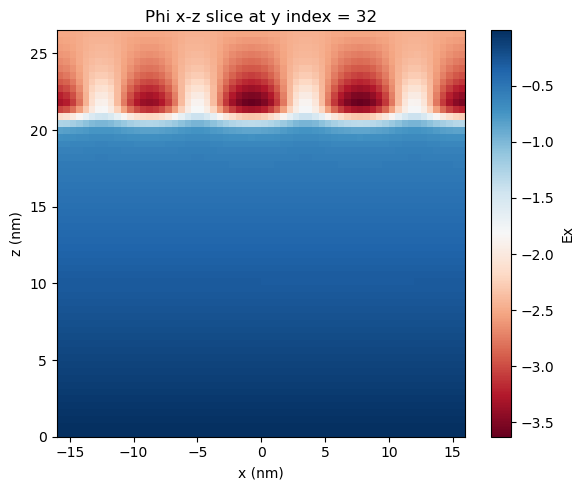

yt : [INFO     ] 2026-06-25 22:50:32,221 Parameters: current_time              = 1.2199199999983734e-08
yt : [INFO     ] 2026-06-25 22:50:32,221 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,221 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,222 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


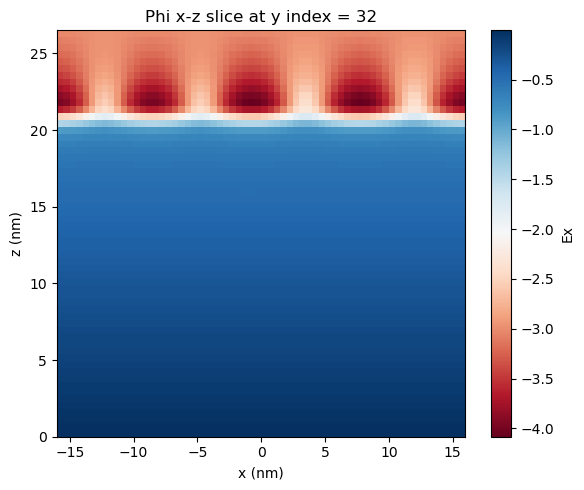

yt : [INFO     ] 2026-06-25 22:50:32,315 Parameters: current_time              = 1.25737999999823e-08
yt : [INFO     ] 2026-06-25 22:50:32,315 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,315 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,315 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


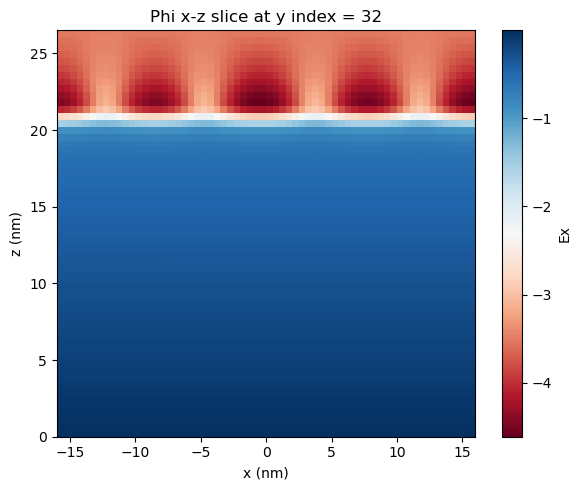

yt : [INFO     ] 2026-06-25 22:50:32,405 Parameters: current_time              = 1.3259599999979674e-08
yt : [INFO     ] 2026-06-25 22:50:32,405 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,405 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,406 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


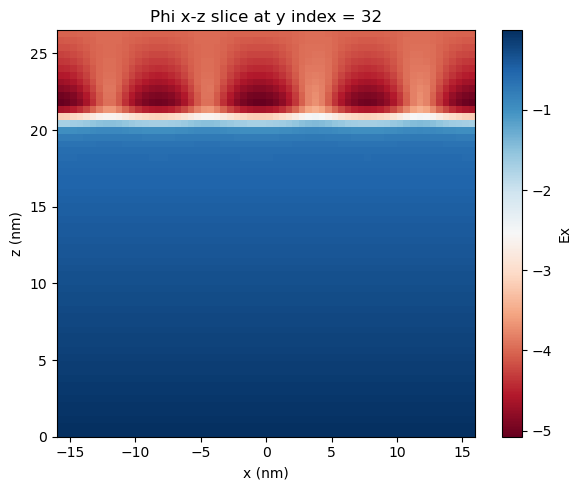

yt : [INFO     ] 2026-06-25 22:50:32,498 Parameters: current_time              = 1.3423399999979046e-08
yt : [INFO     ] 2026-06-25 22:50:32,498 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,498 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,498 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Phi_array shape = (64, 64, 59)


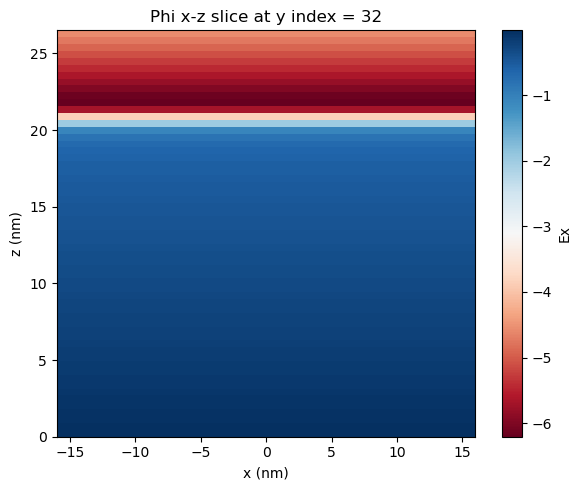

In [13]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-25 22:50:32,596 Parameters: current_time              = 7.363999999999594e-10
yt : [INFO     ] 2026-06-25 22:50:32,596 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,597 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,597 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


E_array shape = (64, 64, 59)


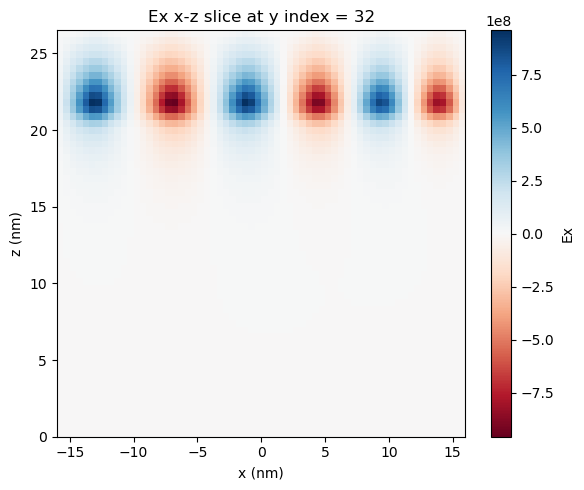

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-06-25 22:50:32,702 Parameters: current_time              = 3.985600000000855e-09
yt : [INFO     ] 2026-06-25 22:50:32,702 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,702 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,702 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]


Plotfiles to draw:
  plt00019928
  plt00021101
  plt00022380
  plt00023913
  plt00025506
  plt00026753
  plt00028079
  plt00029550
  plt00031806
  plt00033230
  plt00034890
  plt00039243
  plt00043046
  plt00044625
  plt00046424
  plt00048972
  plt00051263
  plt00051893
  plt00055857
  plt00055904
  plt00055954
  plt00056008
  plt00056066
  plt00056130
  plt00056200
  plt00056279
  plt00056370
  plt00056478
  plt00056613
  plt00056800
  plt00057120
  plt00057361
  plt00059635
  plt00060996
  plt00062869
  plt00066298
  plt00067117
37 number of plotfiles will be drawn after filtering.


yt : [INFO     ] 2026-06-25 22:50:32,743 Parameters: current_time              = 4.220200000000927e-09
yt : [INFO     ] 2026-06-25 22:50:32,743 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,744 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,744 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]
yt : [INFO     ] 2026-06-25 22:50:32,785 Parameters: current_time              = 4.476000000001006e-09
yt : [INFO     ] 2026-06-25 22:50:32,785 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:32,785 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:32,786 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]
yt : [INFO     ] 2026-06-25 22:50:32,826 Parameters: current_time              = 4.7826000000011e-09
yt : [INFO     ] 2026-06-25 22:50:32,826 Parameters: domain_dimension

yt : [INFO     ] 2026-06-25 22:50:33,803 Parameters: current_time              = 1.122599999998746e-08
yt : [INFO     ] 2026-06-25 22:50:33,803 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:33,804 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:33,804 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]
yt : [INFO     ] 2026-06-25 22:50:33,960 Parameters: current_time              = 1.1239999999987407e-08
yt : [INFO     ] 2026-06-25 22:50:33,960 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:50:33,960 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:50:33,960 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.65e-08]
yt : [INFO     ] 2026-06-25 22:50:34,002 Parameters: current_time              = 1.1255799999987347e-08
yt : [INFO     ] 2026-06-25 22:50:34,002 Parameters: domain_dimen

Drawing 37 plots after filtering.
Saved figure: ./figs/Pz_FE_layer_stack.png


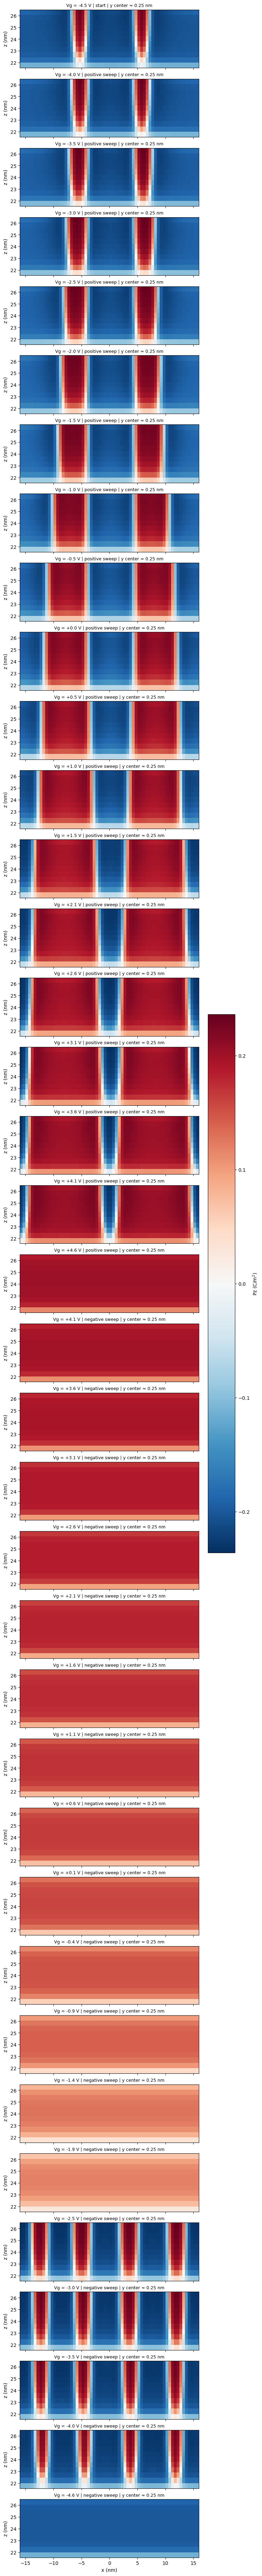

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard
'''
SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]
'''
SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "./figs/Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [17]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [18]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [19]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-26 14:41:50,040 Parameters: current_time              = 3.091200000000581e-09
yt : [INFO     ] 2026-06-26 14:41:50,040 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:50,041 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:50,041 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:50,082 Parameters: current_time              = 3.309800000000648e-09
yt : [INFO     ] 2026-06-26 14:41:50,082 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:50,083 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:50,083 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:50,125 Parameters: current_time              = 3.4874000000007025e-09
yt : [INFO     ] 2026-06-26 14:41:50,125 Parameters: domain_dimens

Finding plotfiles in plts...
['plt00015456', 'plt00016549', 'plt00017437', 'plt00019269', 'plt00019918', 'plt00020641', 'plt00021242', 'plt00021878', 'plt00022493', 'plt00023096', 'plt00023458', 'plt00024167', 'plt00025219', 'plt00026216', 'plt00031232', 'plt00034412', 'plt00036784', 'plt00039995', 'plt00052933', 'plt00054505', 'plt00055378', 'plt00055986', 'plt00057363', 'plt00058328', 'plt00059247', 'plt00059882', 'plt00060153', 'plt00061255', 'plt00061504', 'plt00061915', 'plt00062641', 'plt00067213', 'plt00071247', 'plt00074053', 'plt00076336', 'plt00078438', 'plt00080747']
Read Pz with shape (64, 64, 59) from plts/plt00015456
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00015456 | step=15456 | Vg=-4.5001 V | <Pz>_FE=+9.464355e-02
Read Pz with shape (64, 64, 59) from plts/plt00016549
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00016549 | step=16549 | Vg=-4.0039 V | <Pz>_FE=+8.7664

yt : [INFO     ] 2026-06-26 14:41:50,370 Parameters: current_time              = 4.128200000000899e-09
yt : [INFO     ] 2026-06-26 14:41:50,370 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:50,370 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:50,370 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:50,411 Parameters: current_time              = 4.248400000000936e-09
yt : [INFO     ] 2026-06-26 14:41:50,412 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:50,412 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:50,412 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:50,454 Parameters: current_time              = 4.375600000000975e-09
yt : [INFO     ] 2026-06-26 14:41:50,454 Parameters: domain_dimensi

Read Pz with shape (64, 64, 59) from plts/plt00019918
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00019918 | step=19918 | Vg=-2.5066 V | <Pz>_FE=+6.204457e-02
Read Pz with shape (64, 64, 59) from plts/plt00020641
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00020641 | step=20641 | Vg=-2.0001 V | <Pz>_FE=+4.424042e-02
Read Pz with shape (64, 64, 59) from plts/plt00021242
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00021242 | step=21242 | Vg=-1.4999 V | <Pz>_FE=+3.563410e-02
Read Pz with shape (64, 64, 59) from plts/plt00021878
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00021878 | step=21878 | Vg=-0.9993 V | <Pz>_FE=+2.699784e-02
Read Pz with shape (64, 64, 59) from plts/plt00022493
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt000224

yt : [INFO     ] 2026-06-26 14:41:50,580 Parameters: current_time              = 4.691600000001072e-09
yt : [INFO     ] 2026-06-26 14:41:50,581 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:50,581 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:50,581 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:50,622 Parameters: current_time              = 4.833400000001115e-09
yt : [INFO     ] 2026-06-26 14:41:50,622 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:50,623 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:50,623 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:50,665 Parameters: current_time              = 5.04380000000118e-09
yt : [INFO     ] 2026-06-26 14:41:50,665 Parameters: domain_dimensio

...

Read Pz with shape (64, 64, 59) from plts/plt00059247
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00059247 | step=59247 | Vg=+1.5303 V | <Pz>_FE=-3.590225e-02
Read Pz with shape (64, 64, 59) from plts/plt00059882
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00059882 | step=59882 | Vg=+1.0266 V | <Pz>_FE=-2.280507e-02
Read Pz with shape (64, 64, 59) from plts/plt00060153
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00060153 | step=60153 | Vg=+0.5292 V | <Pz>_FE=-1.911490e-02
Read Pz with shape (64, 64, 59) from plts/plt00061255
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00061255 | step=61255 | Vg=+0.0241 V | <Pz>_FE=-8.018367e-03


yt : [INFO     ] 2026-06-26 14:41:51,528 Parameters: current_time              = 1.238299999998303e-08
yt : [INFO     ] 2026-06-26 14:41:51,528 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:51,528 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:51,528 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:51,571 Parameters: current_time              = 1.2528199999982474e-08
yt : [INFO     ] 2026-06-26 14:41:51,571 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:51,571 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:51,571 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:51,613 Parameters: current_time              = 1.3442599999978973e-08
yt : [INFO     ] 2026-06-26 14:41:51,613 Parameters: domain_dimen

Read Pz with shape (64, 64, 59) from plts/plt00061504
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00061504 | step=61504 | Vg=-0.4752 V | <Pz>_FE=-6.925037e-03
Read Pz with shape (64, 64, 59) from plts/plt00061915
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00061915 | step=61915 | Vg=-0.9737 V | <Pz>_FE=-4.539203e-03
Read Pz with shape (64, 64, 59) from plts/plt00062641
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00062641 | step=62641 | Vg=-1.4855 V | <Pz>_FE=+1.682855e-02
Read Pz with shape (64, 64, 59) from plts/plt00067213
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00067213 | step=67213 | Vg=-1.9893 V | <Pz>_FE=+3.048839e-02
Read Pz with shape (64, 64, 59) from plts/plt00071247
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt000712

yt : [INFO     ] 2026-06-26 14:41:51,741 Parameters: current_time              = 1.5267199999975014e-08
yt : [INFO     ] 2026-06-26 14:41:51,741 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:51,741 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:51,742 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:51,784 Parameters: current_time              = 1.568759999997688e-08
yt : [INFO     ] 2026-06-26 14:41:51,784 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-26 14:41:51,784 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-26 14:41:51,785 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-26 14:41:51,826 Parameters: current_time              = 1.6149399999978933e-08
yt : [INFO     ] 2026-06-26 14:41:51,826 Parameters: domain_dimen

Read Pz with shape (64, 64, 59) from plts/plt00074053
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00074053 | step=74053 | Vg=-2.9965 V | <Pz>_FE=+6.057309e-02
Read Pz with shape (64, 64, 59) from plts/plt00076336
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00076336 | step=76336 | Vg=-3.4923 V | <Pz>_FE=+6.941715e-02
Read Pz with shape (64, 64, 59) from plts/plt00078438
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00078438 | step=78438 | Vg=-3.9962 V | <Pz>_FE=+8.240862e-02
Read Pz with shape (64, 64, 59) from plts/plt00080747
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00080747 | step=80747 | Vg=-4.4998 V | <Pz>_FE=+9.435960e-02
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [20]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


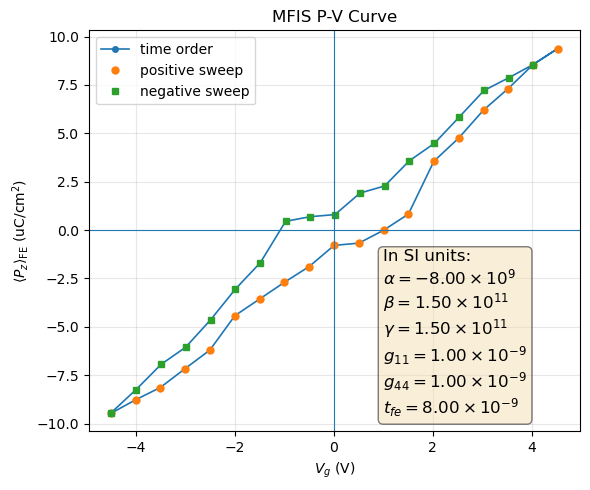

In [21]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()